# EPP Detector — Inferencia con YOLO26

Detección de Equipos de Protección Personal (EPP) en obras de construcción.

**Requisitos previos:**
- Subí el archivo `best.pt` al entorno de Colab (panel izquierdo → 📁 → subir archivo)
- Activá GPU: `Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`

---

## Celda 1 — Verificar GPU

In [6]:
#Verifica CPU
!nvidia-smi
#Instalar dependencias
%pip install -q "ultralytics>=8.4.0" supervision

# Desactivar telemetría de Ultralytics
!yolo settings sync=False

import ultralytics
ultralytics.checks()

#Cargarmodelo
import os
from ultralytics import YOLO

HOME = os.getcwd()

# Ruta al modelo entrenado
# Si subiste best.pt directamente al entorno, la ruta es simplemente 'best.pt'
MODEL_PATH = f'{HOME}/best.pt'

model = YOLO(MODEL_PATH)

print(f'Modelo cargado: {MODEL_PATH}')
print(f'Clases: {model.names}')

#Función de anotación (Bounding boxes y etiquetas)

import supervision as sv
from PIL import Image


def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00",
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    ])

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator(color=color)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out


print('Función annotate() lista.')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)
Modelo cargado: /content/best.pt
Clases: {0: 'helmet', 1: 'no helmet', 2: 'no vest', 3: 'person', 4: 'vest'}
Función annotate() lista.


## Inferencia sobre una imagen propia

Suba una imagen desde tu computadora cuando se le solicite.

Seleccioná una imagen para analizar...


Saving maddybris-man-5680696_1920.jpg to maddybris-man-5680696_1920.jpg
Detecciones encontradas: 2


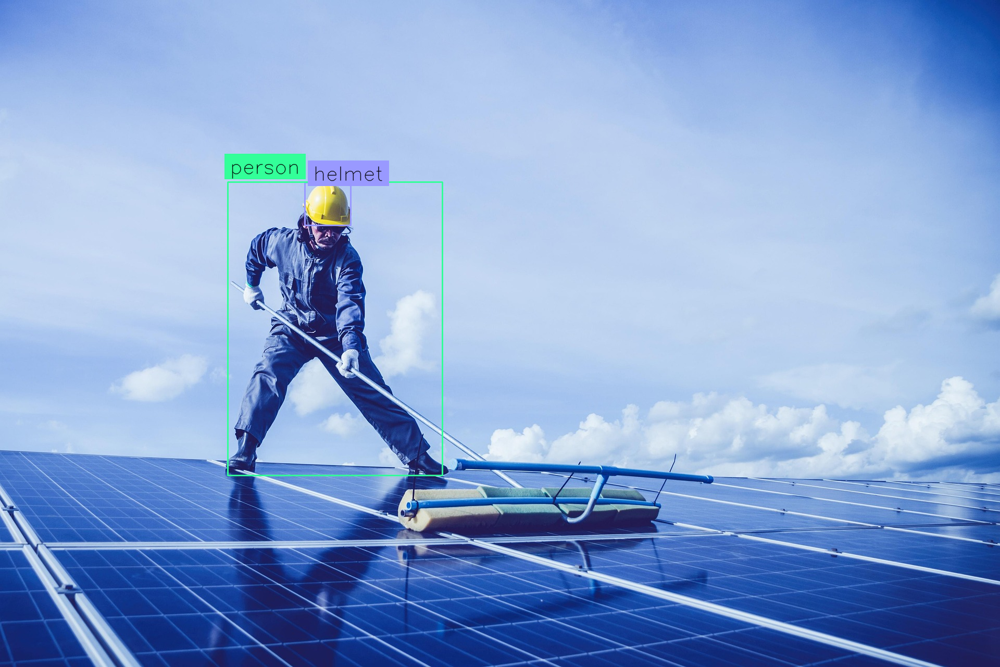

In [7]:
from google.colab import files

print('Seleccioná una imagen para analizar...')
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image_path = f'{HOME}/{image_name}'

with open(image_path, 'wb') as f:
    f.write(uploaded[image_name])

# Inferencia
image = Image.open(image_path)
result = model.predict(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)
annotated_image = annotate(image, detections)

print(f'Detecciones encontradas: {len(detections)}')
annotated_image